In [1]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# 0 - Paths
# ─────────────────────────────────────────────
BASE = "./"

meta_path    = os.path.join(BASE, "CellMetadata_PassQC_alloocytes_withyear_mtreads_sub.csv")
hormone_path = os.path.join(BASE, "PSOAnimalResults-all.csv")
meth_path    = os.path.join(BASE, "mcg_dmg_geneindmatrix.csv")


In [17]:
hormone = pd.read_csv(hormone_path, sep="\t")
hormone1 = hormone.dropna(axis=0, how="all")
hormone2 = hormone1.dropna(axis=1, how="all")
hormone3 = hormone2.drop(columns=["Unnamed: 11"])
hormone4 = hormone3.drop(28)
hormone4

,AnimalID,Cortisol Values ug/dl,Lactate Values ng/mL,Cortisone Values pg/mL,Pyruvate values ng/mL,Progesterone Values pg/mL,Glucose Values mg/mL,Estrogen Values pg/mL,AMH levels! (ng/mL) 2023
0,41237.0,1.58,7.27,4.38,0.54,0.54,4.04,2.47,6.93
1,41460.0,1.29,7.04,4.95,6.49,0.98,4.57,3.77,6.80
2,41391.0,1.40,6.75,5.03,6.47,0.67,4.30,4.25,6.69
3,45208.0,1.27,7.00,5.44,6.29,0.51,3.70,3.92,5.96
4,46363.0,1.28,7.25,4.39,5.66,0.57,4.90,3.46,6.55
5,43028.0,1.51,5.90,4.74,5.54,0.72,5.39,4.21,6.57
6,44218.0,1.17,6.33,4.91,5.79,0.79,3.95,4.73,5.78
7,45669.0,1.24,6.73,4.55,6.35,0.70,2.77,4.23,6.79
8,45982.0,1.26,7.07,4.70,4.56,0.82,3.79,4.19,6.06
9,43051.0,1.39,6.99,5.19,6.24,0.87,4.34,3.64,6.81


In [2]:

# ─────────────────────────────────────────────
# 1 - Load metadata, keep pooled only
# ─────────────────────────────────────────────
meta   = pd.read_csv(meta_path, sep="\t")
meta["AnimalID"] = meta["AnimalID"].astype(str)
pooled = meta[meta["Type"] == "PO"].copy()

# ─────────────────────────────────────────────
# 2 - Load & align methylation matrix
# ─────────────────────────────────────────────
meth_mat = pd.read_csv(meth_path, index_col=0)
meth_mat = meth_mat.T
meth_mat.index = meth_mat.index.str.lstrip("X")

common_samps    = meth_mat.index.intersection(pooled["SampleID"])
meth2           = meth_mat.loc[common_samps]
pooled2         = pooled.set_index("SampleID").loc[common_samps].reset_index()
pooled2["AnimalID"] = pooled2["AnimalID"].astype(int)

print(f"Common samples: {len(common_samps)}")

# ─────────────────────────────────────────────
# 3 - Roll-up methylation to animal means
# ─────────────────────────────────────────────
expr_df             = meth2.copy()
expr_df["AnimalID"] = pooled2["AnimalID"].values
animal_expr         = expr_df.groupby("AnimalID").mean()

print(f"Animals: {animal_expr.shape[0]}, Genes: {animal_expr.shape[1]}")

# ─────────────────────────────────────────────
# 4 - Load hormones & merge onto animal means
# ─────────────────────────────────────────────
hormone = pd.read_csv(hormone_path, sep="\t")
hormone1 = hormone.dropna(axis=0, how="all")
hormone2 = hormone1.dropna(axis=1, how="all")
hormone3 = hormone2.drop(columns=["Unnamed: 11"])
hormone4 = hormone3.drop(28)
hormone = hormone4
hormone.rename(columns={hormone.columns[0]: "AnimalID"}, inplace=True)
hormone["AnimalID"] = hormone["AnimalID"].astype(int)

hormone_rename = {
    "Cortisol Values ug/dl"     : "Cortisol",
    "Lactate Values ng/mL"      : "Lactate",
    "Cortisone Values pg/mL"    : "Cortisone",
    "Pyruvate values ng/mL"     : "Pyruvate",
    "Progesterone Values pg/mL" : "Progesterone",
    "Glucose Values mg/mL"      : "Glucose",
    "Estrogen Values pg/mL"     : "Estrogen",
    "AMH levels! (ng/mL) 2023"  : "AMH"
}
hormone.rename(columns=hormone_rename, inplace=True)

# Also bring in Group from pooled2
animal_group = (pooled2[["AnimalID","Group"]]
                .drop_duplicates(subset="AnimalID")
                .set_index("AnimalID"))

animal_df = (animal_expr
             .join(animal_group, how="left")
             .reset_index()
             .merge(hormone[["AnimalID"] + list(hormone_rename.values())],
                    on="AnimalID")
             .set_index("AnimalID"))

print(f"animal_df shape: {animal_df.shape}")
print("Missing hormone values:")
print(animal_df[list(hormone_rename.values())].isna().sum())

Common samples: 46
Animals: 16, Genes: 75
animal_df shape: (14, 84)
Missing hormone values:
Cortisol        0
Lactate         0
Cortisone       0
Pyruvate        0
Progesterone    0
Glucose         0
Estrogen        0
AMH             0
dtype: int64


In [3]:
animal_df


,HOXC12,GSX1,FEV,SOX18,FOXA2,WNT1,SSNA1,FOXQ1,ENSMMUG00000061107,SKIDA1,...,"MT-ND5, MT-ND6, MT-TE, MT-CYB",Group,Cortisol,Lactate,Cortisone,Pyruvate,Progesterone,Glucose,Estrogen,AMH
AnimalID,,,,,,,,,,,,,,,,,,,,,
41237,0.116580,0.058550,0.037696,0.039574,0.025078,0.066532,0.102312,0.041277,0.060304,0.130930,...,0.353422,Stressed,1.58,7.27,4.38,0.54,0.54,4.04,2.47,6.93
41299,0.744089,0.954632,0.578135,1.000000,0.453992,0.524181,1.000000,1.000000,0.717680,0.819814,...,0.236073,Stressed,1.26,6.92,4.16,4.25,0.33,3.95,3.79,6.58
41391,0.206527,0.254362,0.111242,0.076372,0.071867,0.082716,0.258528,0.199439,0.206971,0.238722,...,0.623249,Control,1.40,6.75,5.03,6.47,0.67,4.30,4.25,6.69
41460,0.253664,0.272879,0.146734,0.273847,0.160447,0.122686,0.385686,0.409979,0.125161,0.137964,...,0.515436,Control,1.29,7.04,4.95,6.49,0.98,4.57,3.77,6.80
42111,0.078678,0.135406,0.107660,1.000000,0.113279,0.080980,0.876480,0.081543,0.520826,0.165662,...,0.574248,Control,1.24,6.39,3.70,6.22,0.70,3.31,3.67,5.55
42651,0.787378,0.701235,0.167246,0.729370,0.074628,0.085079,1.045935,0.725950,0.462395,0.669250,...,0.162209,Stressed,1.32,7.16,5.07,6.40,0.61,3.63,3.85,6.80
43028,0.066317,0.053392,0.036422,0.027659,0.030394,0.055186,0.274856,0.031854,0.067458,0.078575,...,0.428952,Control,1.51,5.90,4.74,5.54,0.72,5.39,4.21,6.57
44564,0.144362,0.033479,0.037877,0.094828,0.071239,0.073841,0.139331,1.000000,0.090563,0.207184,...,0.409257,Control,1.52,6.77,5.53,6.10,1.53,3.50,4.79,5.23
44994,0.182833,0.076727,0.040449,0.076727,0.173375,0.263153,1.000000,0.037819,0.146098,0.244947,...,1.000000,Control,1.44,6.53,5.05,6.22,0.83,3.62,3.87,6.07


In [4]:
from scipy import stats

# ─────────────────────────────────────────────
# 5 - Pearson Correlation
# ─────────────────────────────────────────────
hormones = list(hormone_rename.values())

hormone_groups = {
    "Cortisol"    : "Stress",
    "Cortisone"   : "Stress",
    "Lactate"     : "Metabolite",
    "Pyruvate"    : "Metabolite",
    "Glucose"     : "Metabolite",
    "Progesterone": "Reproductive",
    "Estrogen"    : "Reproductive",
    "AMH"         : "Reproductive"
}

genes = [c for c in animal_expr.columns]

results = []

for h in hormones:
    for g in genes:
        df_a = animal_df[[g, h, "Group"]].rename(
            columns={g: "expression", h: "hormone"}
        ).dropna()

        # Remove Progesterone outliers using IQR
        if h == "Progesterone":
            q1, q3 = df_a["hormone"].quantile([0.25, 0.75])
            iqr    = q3 - q1
            df_a   = df_a[
                (df_a["hormone"] >= q1 - 1.5*iqr) &
                (df_a["hormone"] <= q3 + 1.5*iqr)
            ]

        if len(df_a) < 3:
            continue

        r, pval = stats.pearsonr(df_a["hormone"], df_a["expression"])

        if pval >= 0.05:
            continue

        results.append({
            "Hormone"       : h,
            "Hormone_Group" : hormone_groups[h],
            "Gene"          : g,
            "r"             : round(r, 3),
            "p_corr"        : float(f"{pval:.3g}")
        })

results_df = pd.DataFrame(results)
print(f"Significant pairs (p < 0.05): {len(results_df)}")
print(results_df.groupby("Hormone_Group")["Gene"].count())



Significant pairs (p < 0.05): 37
Hormone_Group
Metabolite       1
Reproductive    15
Stress          21
Name: Gene, dtype: int64


In [5]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
# ─────────────────────────────────────────────
# 6 - BH FDR Correction Within Each Hormone Group
# ─────────────────────────────────────────────
def apply_bh(group):
    _, p_adj, _, _ = multipletests(group["p_corr"], method="fdr_bh")
    group = group.copy()
    group["p_adj_BH"] = p_adj
    return group

results_df = (results_df
              .groupby("Hormone_Group", group_keys=False)
              .apply(apply_bh))

results_df["sig_nominal"] = results_df["p_corr"]   < 0.05
results_df["sig_FDR"]     = results_df["p_adj_BH"] < 0.05

print("\nNominal significant pairs (p < 0.05) per hormone group:")
print(results_df[results_df["sig_nominal"]].groupby("Hormone_Group").size())

print("\nFDR significant pairs (BH < 0.05) per hormone group:")
print(results_df[results_df["sig_FDR"]].groupby("Hormone_Group").size())



Nominal significant pairs (p < 0.05) per hormone group:
Hormone_Group
Metabolite       1
Reproductive    15
Stress          21
dtype: int64

FDR significant pairs (BH < 0.05) per hormone group:
Hormone_Group
Metabolite       1
Reproductive    15
Stress          21
dtype: int64


In [10]:
results_df.to_csv("correlation_results_grouprfbyhormone.csv", index=False)
print("Saved correlation_results.csv")
print(results_df.shape)
print(results_df.head())

Saved correlation_results.csv
(37, 8)
    Hormone Hormone_Group                Gene      r   p_corr  p_adj_BH  \
0  Cortisol        Stress                 FEV -0.536  0.04800   0.04980   
1  Cortisol        Stress               SOX18 -0.545  0.04380   0.04980   
2  Cortisol        Stress               SSNA1 -0.534  0.04910   0.04980   
3  Cortisol        Stress  ENSMMUG00000061107 -0.682  0.00727   0.02241   
4  Cortisol        Stress               H2BC6 -0.615  0.01920   0.04032   

   sig_nominal  sig_FDR  
0         True     True  
1         True     True  
2         True     True  
3         True     True  
4         True     True  


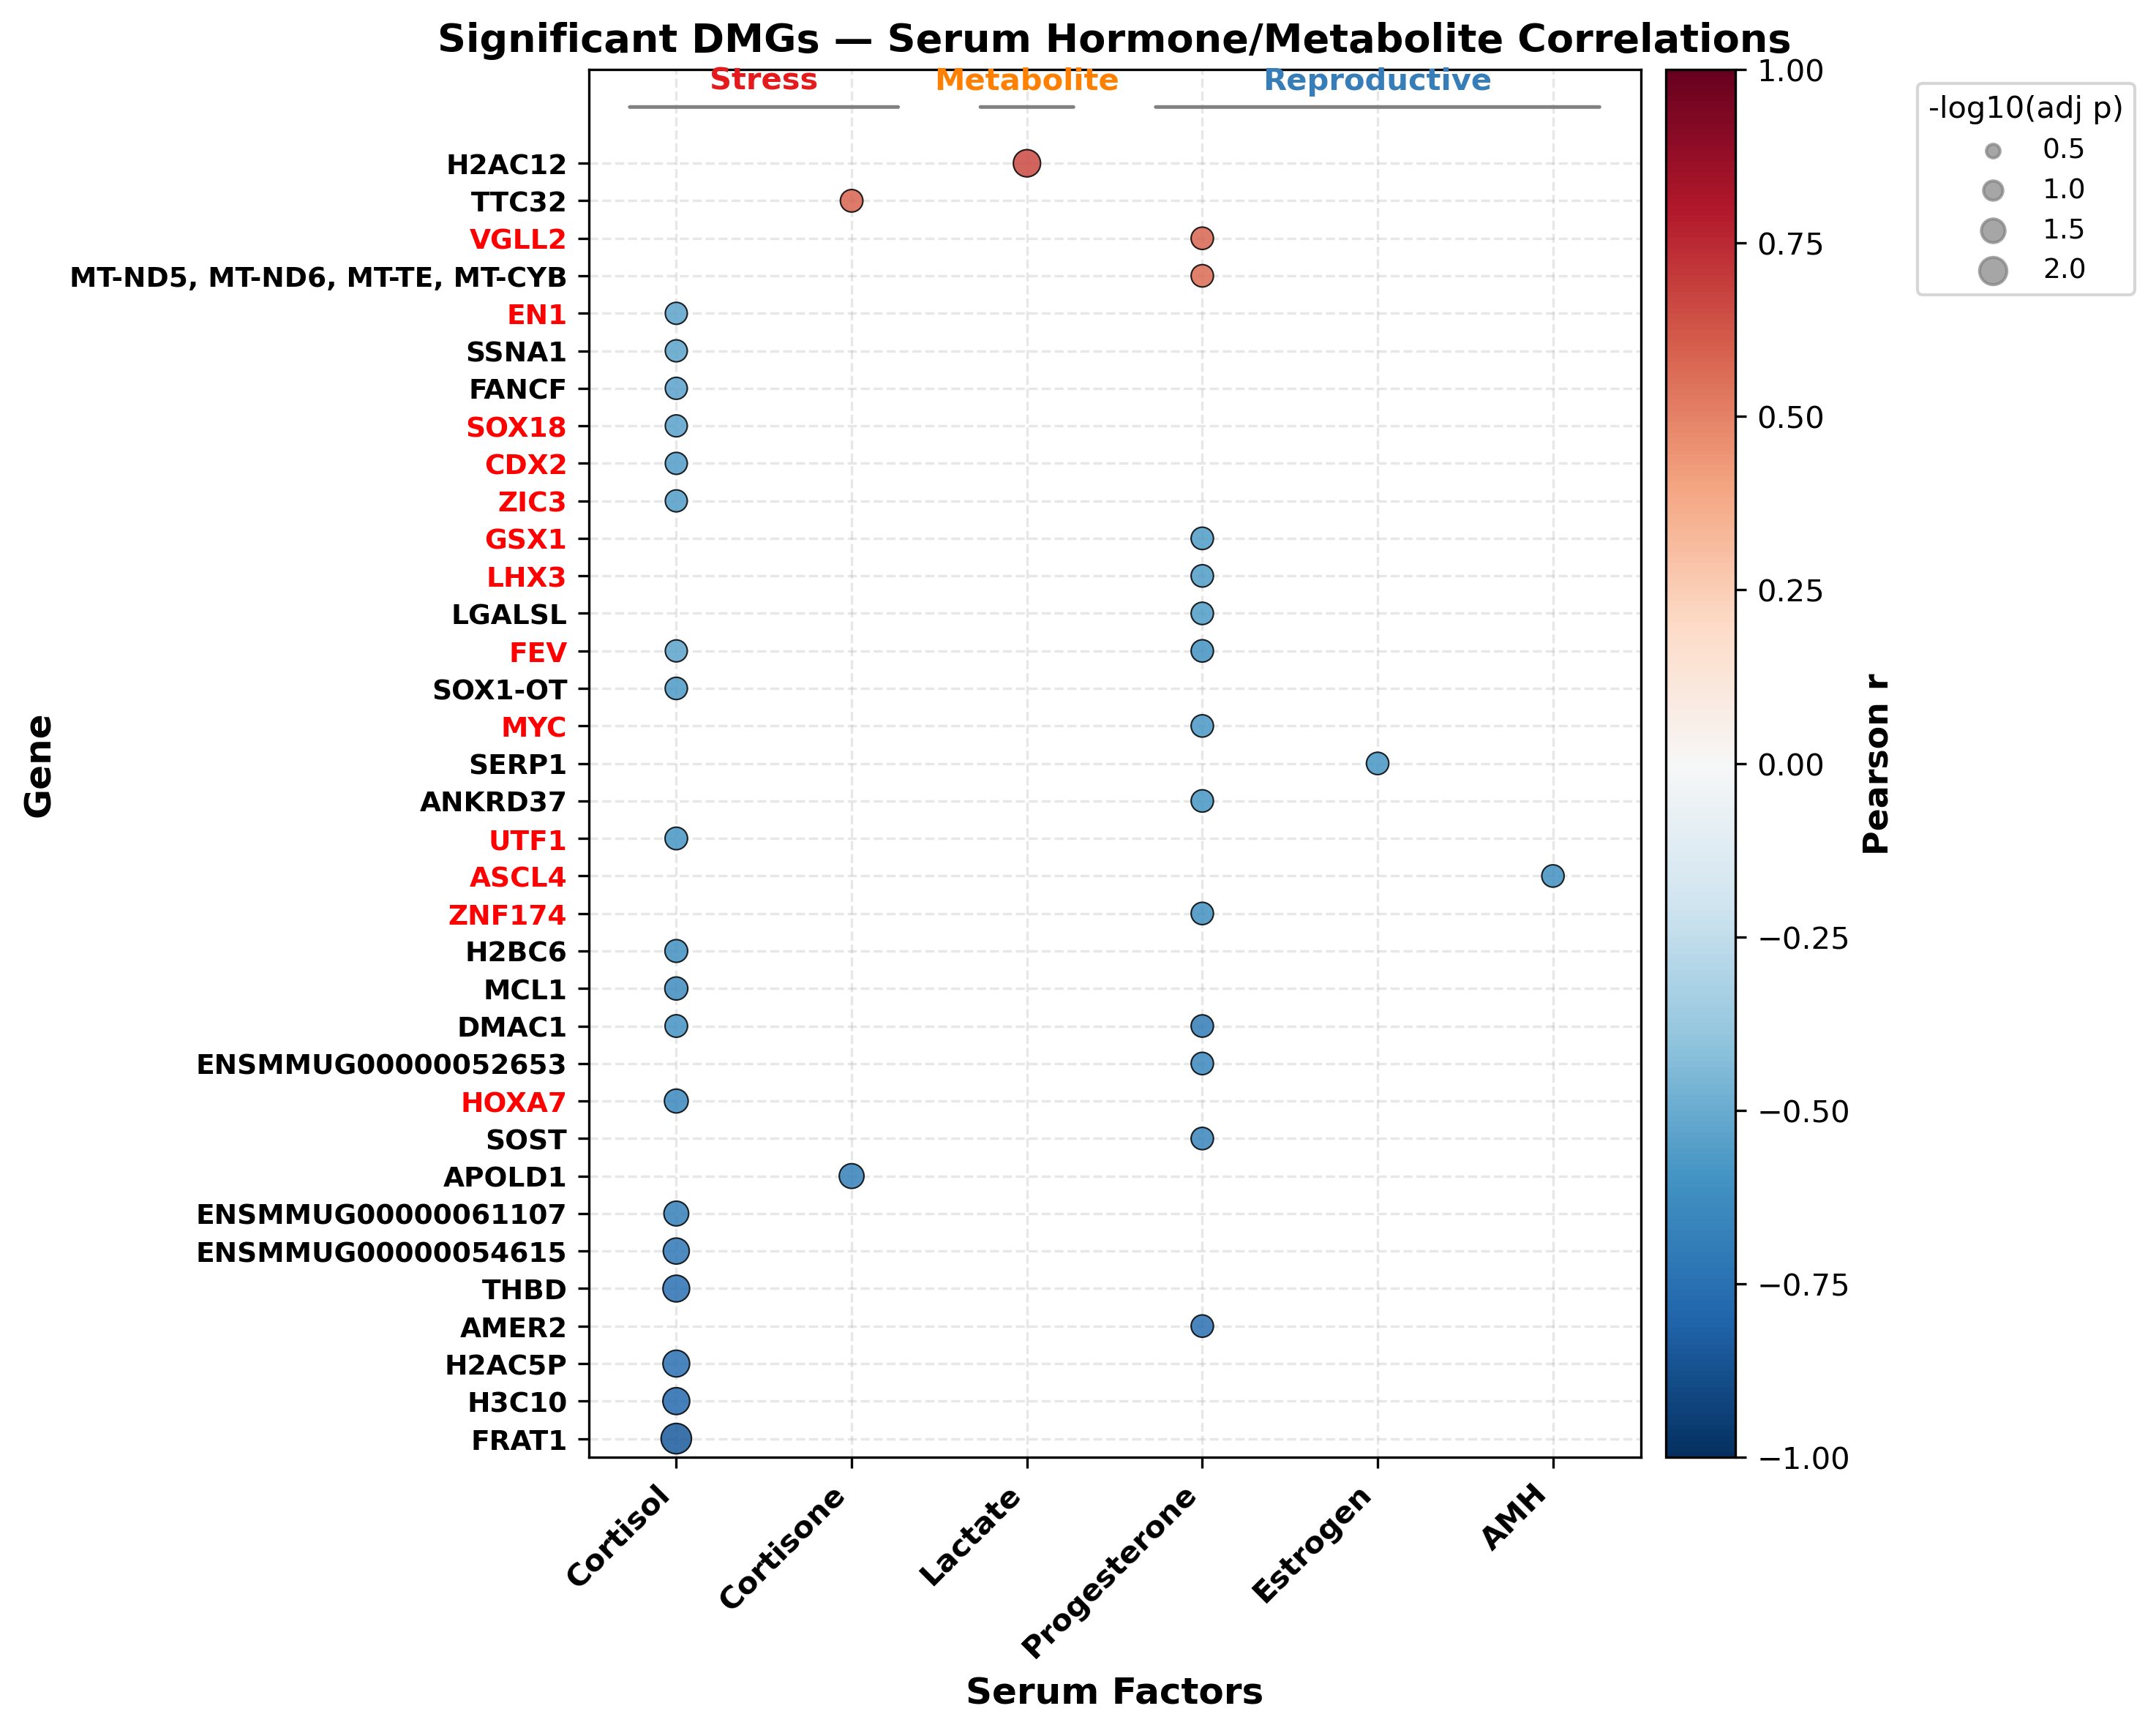

In [12]:
#plot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['path.simplify'] = False  # keep exact vectors


tf_genes = {
    'HOXC12', 'GSX1', 'FEV', 'SOX18', 'FOXA2', 'FOXQ1', 'HOXB13', 'BARHL2',
    'CITED2', 'HOXD12', 'UTF1', 'MYC', 'HOXD1', 'PURB', 'PHF10', 'LHX3',
    'DLX3', 'LHX5', 'ASCL4', 'EN1', 'TCF19', 'ZNF174', 'ZIC3', 'ZIC1',
    'FLI1', 'CDX2', 'NKX1-2', 'HOXA7', 'VGLL2'
}

hormone_groups = {
    "Cortisol"    : "Stress",
    "Cortisone"   : "Stress",
    "Lactate"     : "Metabolite",
    "Pyruvate"    : "Metabolite",
    "Glucose"     : "Metabolite",
    "Progesterone": "Reproductive",
    "Estrogen"    : "Reproductive",
    "AMH"         : "Reproductive"
}

df_plot = results_df[results_df["sig_nominal"]].copy()
df_plot["logp"]     = -np.log10(df_plot["p_corr"])
df_plot["logp_adj"] = -np.log10(df_plot["p_adj_BH"])

# Order genes by mean r
gene_order = (df_plot.groupby("Gene")["r"]
              .mean()
              .sort_values()
              .index.tolist())

hormone_order = ["Cortisol","Cortisone",
                 "Lactate","Pyruvate","Glucose",
                 "Progesterone","Estrogen","AMH"]
hormone_order = [h for h in hormone_order if h in df_plot["Hormone"].unique()]

df_plot["Gene"]    = pd.Categorical(df_plot["Gene"],    categories=gene_order,    ordered=True)
df_plot["Hormone"] = pd.Categorical(df_plot["Hormone"], categories=hormone_order, ordered=True)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(vmin=-1, vmax=1)

sc = ax.scatter(
    df_plot["Hormone"].cat.codes,
    df_plot["Gene"].cat.codes,
    c          = df_plot["r"],
    s          = df_plot["logp_adj"] * 40,   # size = -log10(adj p)
    cmap       = cmap,
    norm       = norm,
    alpha      = 0.85,
    edgecolors = "black",
    linewidths = 0.5,
    zorder     = 3
)

# ── x axis: hormone labels with group brackets ──
ax.set_xticks(range(len(hormone_order)))
ax.set_xticklabels(hormone_order, rotation=45, ha="right",
                   fontsize=10, fontweight="bold")

group_positions = {"Stress": [], "Metabolite": [], "Reproductive": []}
for i, h in enumerate(hormone_order):
    group_positions[hormone_groups[h]].append(i)

group_colours = {"Stress":"#E41A1C", "Metabolite":"#FF7F00", "Reproductive":"#377EB8"}

for grp, positions in group_positions.items():
    if not positions:
        continue
    mid = np.mean(positions)
    ax.annotate(grp,
                xy=(mid, len(gene_order) + 0.8),
                ha="center", va="bottom",
                fontsize=10, fontweight="bold",
                color=group_colours[grp])
    ax.annotate("",
                xy     =(positions[0]  - 0.3, len(gene_order) + 0.5),
                xytext =(positions[-1] + 0.3, len(gene_order) + 0.5),
                arrowprops=dict(arrowstyle="-", color="grey", lw=1.2))

# ── y axis: gene labels, TFs in red ──
ax.set_yticks(range(len(gene_order)))
ax.set_yticklabels(gene_order, fontsize=9, fontweight="bold")
for tick, gene in zip(ax.get_yticklabels(), gene_order):
    tick.set_color("red" if gene in tf_genes else "black")

# ── colourbar ──
cbar = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax, pad=0.02
)
cbar.set_label("Pearson r", fontsize=11, fontweight="bold")

# ── size legend: adjusted p ──
for logp_val, label in zip([0.5, 1.0, 1.5, 2.0], ["0.5","1.0","1.5","2.0"]):
    ax.scatter([], [], s=logp_val*40, c="grey",
               alpha=0.7, label=label)

ax.legend(title="-log10(adj p)", bbox_to_anchor=(1.25, 1),
          loc="upper left", fontsize=9, title_fontsize=10)

ax.set_xlim(-0.5, len(hormone_order) - 0.5)
ax.set_ylim(-0.5, len(gene_order) + 1.5)
ax.set_xlabel("Serum Factors", fontsize=12, fontweight="bold")
ax.set_ylabel("Gene",          fontsize=12, fontweight="bold")
ax.set_title("Significant DMGs — Serum Hormone/Metabolite Correlations",
             fontsize=13, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("dotplot_by_hormone_group.png", dpi=300, bbox_inches="tight")
plt.savefig("dotplot_by_hormone_group.pdf", bbox_inches="tight")
plt.show()

In [23]:
# group hormones based on hypothesis 
from scipy import stats
from statsmodels.stats.multitest import multipletests

hormones = list(hormone_rename.values())

hormone_groups = {
    "Cortisol"    : "Stress",
    "Cortisone"   : "Other",
    "Lactate"     : "Other",
    "Pyruvate"    : "Other",
    "Glucose"     : "Other",
    "Progesterone": "Stress",
    "Estrogen"    : "Other",
    "AMH"         : "Other"
}

genes = [c for c in animal_expr.columns]

# ─────────────────────────────────────────────
# 5 - Pearson Correlation: gene x hormone
# ─────────────────────────────────────────────
results = []

for h in hormones:
    for g in genes:
        df_a = animal_df[[g, h, "Group"]].rename(
            columns={g: "expression", h: "hormone"}
        ).dropna()

        # Remove Progesterone outliers (IQR method)
        if h == "Progesterone":
            q1, q3 = df_a["hormone"].quantile([0.25, 0.75])
            iqr    = q3 - q1
            df_a   = df_a[
                (df_a["hormone"] >= q1 - 1.5*iqr) &
                (df_a["hormone"] <= q3 + 1.5*iqr)
            ]

        if len(df_a) < 3:
            continue

        r, pval = stats.pearsonr(df_a["hormone"], df_a["expression"])

        results.append({
            "Hormone"       : h,
            "Hormone_Group" : hormone_groups[h],
            "Gene"          : g,
            "r"             : round(r, 3),
            "p_corr"        : pval
        })

results_df = pd.DataFrame(results)
print(f"Total gene-hormone pairs tested: {len(results_df)}")

# ─────────────────────────────────────────────
# 6 - BH FDR Correction Within Each Hormone Group
# ─────────────────────────────────────────────
def apply_bh(group):
    _, p_adj, _, _ = multipletests(group["p_corr"], method="fdr_bh")
    group = group.copy()
    group["p_adj_BH"] = p_adj
    return group

results_df = (results_df
              .groupby("Hormone_Group", group_keys=False)
              .apply(apply_bh))

results_df["sig_nominal"] = results_df["p_corr"]   < 0.05
results_df["sig_FDR"]     = results_df["p_adj_BH"] < 0.05

print("\nNominal significant pairs (p < 0.05) per hormone group:")
print(results_df[results_df["sig_nominal"]].groupby("Hormone_Group").size())

print("\nFDR significant pairs (BH < 0.05) per hormone group:")
print(results_df[results_df["sig_FDR"]].groupby("Hormone_Group").size())

Total gene-hormone pairs tested: 600

Nominal significant pairs (p < 0.05) per hormone group:
Hormone_Group
Other      5
Stress    32
dtype: int64

FDR significant pairs (BH < 0.05) per hormone group:
Hormone_Group
Stress    1
dtype: int64


In [33]:
sig_df = results_df[results_df["sig_FDR"] == True]
sig_df

,Hormone,Hormone_Group,Gene,r,p_corr,p_adj_BH,sig_nominal,sig_FDR
19,Cortisol,Stress,FRAT1,-0.842,0.000156,0.023442,True,True
